### Importation of the libraries 

In [ ]:
%pip install numpy 
%pip install pandas 
%pip install matplotlib 
%pip install seaborn 
%pip install scikit-learn 
%pip install torch 
%pip install scikit-optimize 
%pip install xgboost
%pip install openpyxl
%pip install tabulate
%pip install statsmodels
%pip install shap

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RepeatedStratifiedKFold
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from xgboost import XGBClassifier
import openpyxl

### Loading the Data

In [8]:
df = pd.read_excel("Veave - Analyse NTs_Adult_230126-R.xlsx", sheet_name="NTadu-R-stack")

<span style="color:yellow"> With the info command I have information about the data structure, including the number of rows, colums, data types and non-null values for each variables</span>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           86 non-null     object 
 1   Cohort           86 non-null     object 
 2   Group            86 non-null     object 
 3   Cage             86 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             86 non-null     object 
 6   Sample Name      0 non-null      float64
 7   Sex              86 non-null     object 
 8   Area             86 non-null     object 
 9   Sample Name.1    86 non-null     object 
 10  5HTP             86 non-null     object 
 11  Adénosine        86 non-null     object 
 12  Adrénaline       2 non-null      object 
 13  Dopamine         86 non-null     object 
 14  GABA             86 non-null     object 
 15  Glutamate        86 non-null     object 
 16  Glutamine        86 non-null     object 
 17  Kynurénine       8

<span style="color:yellow"> The metabolite columns are shown as `object` due to the presence of a non-numeric value (`"x"`) in one sample. </span>

<span style="color:yellow"> After identifying this invalid entry, the corresponding row was removed </span>

In [10]:
mask = df["GABA"].apply(lambda x: isinstance(x, str))
print(df.loc[mask])
df = df[~mask] # Remove that line from the dataframe
df = df.reset_index(drop=True) # Reset the index of the dataframe since we removed a row

   Projet     Cohort Group  Cage  ID  ID.2  Sample Name     Sex Area  \
60  VEAVE  Cohorte 3  CONT    14 NaN  14-6          NaN  Female  HIP   

   Sample Name.1  ... GABA Glutamate Glutamine Kynurénine Noradrénaline  \
60         14-6_  ...    x         x         x          x             x   

   Normétanéphrine Sérotonine Tryptophane Tyramine Tyrosine  
60               x          x           x        x        x  

[1 rows x 24 columns]


<span style="color:yellow"> And the metabolite columns were converted to numeric format. </span>

In [11]:
nts = [
    "5HTP", "Adénosine", "Adrénaline", "Dopamine", "GABA",
    "Glutamate", "Glutamine", "Kynurénine",
    "Noradrénaline", "Normétanéphrine",
    "Sérotonine", "Tryptophane", "Tyramine", "Tyrosine"
]

for col in nts:
    df[col] = pd.to_numeric(df[col], errors="coerce") # Convert the columns to numeric

<span style="color:yellow"> Now we can observe that the metabolites are shown as `float64` </span>

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           85 non-null     object 
 1   Cohort           85 non-null     object 
 2   Group            85 non-null     object 
 3   Cage             85 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             85 non-null     object 
 6   Sample Name      0 non-null      float64
 7   Sex              85 non-null     object 
 8   Area             85 non-null     object 
 9   Sample Name.1    85 non-null     object 
 10  5HTP             85 non-null     float64
 11  Adénosine        85 non-null     float64
 12  Adrénaline       0 non-null      float64
 13  Dopamine         85 non-null     float64
 14  GABA             85 non-null     float64
 15  Glutamate        85 non-null     float64
 16  Glutamine        85 non-null     float64
 17  Kynurénine       8

## Cleaning / Preparation / Visualisation of the Data

### Cleaning the Data 

<span style="color:yellow"> We decided that any data that has a : </span><span style="color:red"> GABA value superior to 21 </span> <span style="color:yellow"> are considered as outliers: </span>

<span style="color:yellow"> Here's a representation of these outliers </span>

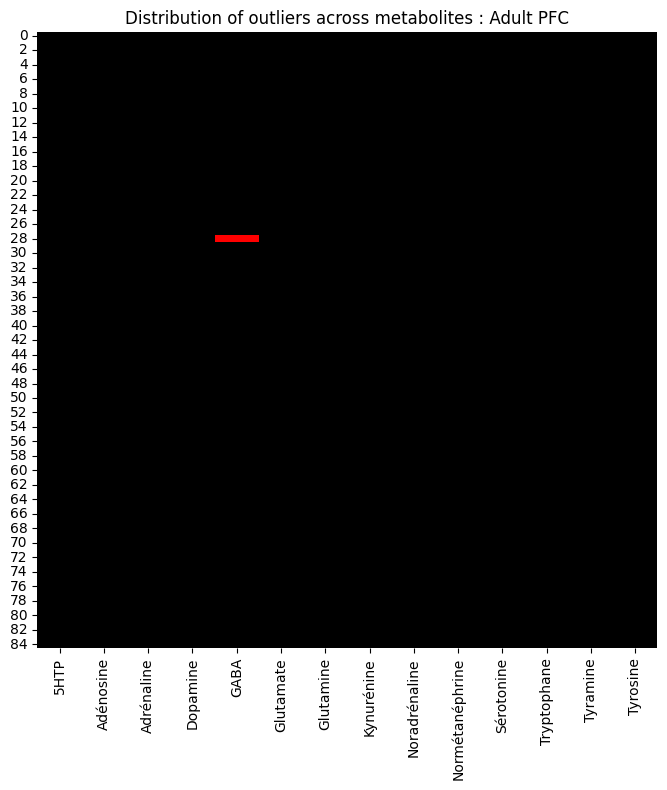

In [14]:
mask = (df['GABA'] > 21)

outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)
outlier_mask.loc[mask, ["GABA"]] = True

nts = [
    "5HTP",
    "Adénosine",
    "Adrénaline",
    "Dopamine",
    "GABA",
    "Glutamate",
    "Glutamine",
    "Kynurénine",
    "Noradrénaline",
    "Normétanéphrine",
    "Sérotonine",
    "Tryptophane",
    "Tyramine",
    "Tyrosine"
]

plt.figure(figsize=(8, 8))
sns.heatmap(
    outlier_mask[nts],
    linewidths=0,
    cmap=["black", "red"],
    cbar=False
)
plt.title("Distribution of outliers across metabolites : Adult PFC")
plt.show()

<span style="color:yellow"> For more information about that outlier  </span>

In [15]:
print(df.loc[mask])

   Projet     Cohort Group  Cage  ID  ID.2  Sample Name     Sex Area  \
28  VEAVE  Cohorte 3  CONT    18 NaN  18-1          NaN  female  PFC   

   Sample Name.1  ...   GABA  Glutamate  Glutamine  Kynurénine  Noradrénaline  \
28         18-1_  ...  21.63      7.197     0.5289    0.002358           2.49   

    Normétanéphrine  Sérotonine  Tryptophane  Tyramine  Tyrosine  
28            6.567     0.09077       0.9024   0.01267     4.856  

[1 rows x 24 columns]


<span style="color:yellow"> Now we remove that value </span>

In [18]:
df = df[
    ~(
        (df['GABA'] > 21)
    )
]
df = df.reset_index(drop=True) # Reset the index of the dataframe since we removed a row

<span style="color:yellow"> Now we homogenize the the values of the Sex columns (ex : Male, male, Female, female) </span>

In [ ]:
df["Sex"] = df["Sex"].str.lower() # So now there is now only lowercase values in the "Sex" column

<span style="color:yellow"> So the different columns are : </span>

In [20]:
print(f"The columns in the dataset are: {df.columns}")

The columns in the dataset are: Index(['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex',
       'Area', 'Sample Name.1', '5HTP', 'Adénosine', 'Adrénaline', 'Dopamine',
       'GABA', 'Glutamate', 'Glutamine', 'Kynurénine', 'Noradrénaline',
       'Normétanéphrine', 'Sérotonine', 'Tryptophane', 'Tyramine', 'Tyrosine'],
      dtype='object')


### Separation of the Data by Area

<span style="color:yellow"> Here we seperate the data into 2 dataset : For the PFC, HIP</span>

In [21]:
NT_df_pfc_adu = df.query("Area == 'PFC'").copy()
NT_df_hip_adu = df.query("Area == 'HIP'").copy()

<span style="color:yellow"> Now, for the number of individuals in each group for each Area. </span>

In [22]:
print(f" --In the PFC group--:",NT_df_pfc_adu['Group'].value_counts())


 --In the PFC group--: Group
LBN     25
CONT    17
Name: count, dtype: int64


In [23]:
print(f" --In the HIP group-- :",NT_df_hip_adu['Group'].value_counts())

 --In the HIP group-- : Group
LBN     25
CONT    17
Name: count, dtype: int64


<span style="color:yellow"> Now, the count of individuals broken down by sex cohort and cage, per area. </span>

#### For the PFC 

In [24]:
print("For the PFC Area : ")
print(
    NT_df_pfc_adu
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)

For the PFC Area : 
   Group     Sex     Cohort  Cage  N
0   CONT  female  Cohorte 3    14  3
1   CONT  female  Cohorte 3    17  4
2   CONT  female  Cohorte 3    18  3
3   CONT    male  Cohorte 3    13  2
4   CONT    male  Cohorte 3    19  5
5    LBN  female  Cohorte 3    12  3
6    LBN  female  Cohorte 3    16  3
7    LBN  female  Cohorte 3    20  2
8    LBN    male  Cohorte 3    10  5
9    LBN    male  Cohorte 3    11  5
10   LBN    male  Cohorte 3    15  3
11   LBN    male  Cohorte 3    21  4


#### For the HIP

In [25]:
print("\nFor the HIP Area :")
print(
    NT_df_hip_adu
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the HIP Area :
   Group     Sex     Cohort  Cage  N
0   CONT  female  Cohorte 3    14  2
1   CONT  female  Cohorte 3    17  4
2   CONT  female  Cohorte 3    18  4
3   CONT    male  Cohorte 3    13  2
4   CONT    male  Cohorte 3    19  5
5    LBN  female  Cohorte 3    12  3
6    LBN  female  Cohorte 3    16  3
7    LBN  female  Cohorte 3    20  2
8    LBN    male  Cohorte 3    10  5
9    LBN    male  Cohorte 3    11  5
10   LBN    male  Cohorte 3    15  3
11   LBN    male  Cohorte 3    21  4


### Seperation of the Data into 2 Dataset : X (Predictors : Variables - NTS ) and Y (Outcome : Group - LBN vs CONT)

In [ ]:
columns_to_drop = ['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex','Area', 'Sample Name.1','Adrénaline']
X_adu_pfc = NT_df_pfc_adu.drop(columns=columns_to_drop)
Y_adu_pfc = NT_df_pfc_adu['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_adu_hip = NT_df_hip_adu.drop(columns=columns_to_drop)
Y_adu_hip = NT_df_hip_adu['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)

#### Transformation Log 

In [ ]:
X_adu_pfc_log = np.log1p(X_adu_pfc)
X_adu_hip_log = np.log1p(X_adu_hip)

## Analysis

### Principal Component Analysis (PCA)

---

#### For the PFC

In [ ]:
scaler = StandardScaler()
X_adu_pfc_scaled = scaler.fit_transform(X_adu_pfc_log)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_adu_pfc_pca = pca.fit_transform(X_adu_pfc_scaled)

In [ ]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_adu_pfc_pca[Y_adu_pfc ==0, 0],
    X_adu_pfc_pca[Y_adu_pfc ==0, 1],
    label="CONT"
)

plt.scatter(
    X_adu_pfc_pca[Y_adu_pfc ==1, 0],
    X_adu_pfc_pca[Y_adu_pfc ==1, 1],
    label="LBN"
)

plt.title("PCA of PFC Neurotransmitters")
plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend()
plt.show()

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_adu_pfc_pca[Y_adu_pfc==0,0],
    X_adu_pfc_pca[Y_adu_pfc==0,1],
    X_adu_pfc_pca[Y_adu_pfc==0,2],
    label="CONT"
)

ax.scatter(
    X_adu_pfc_pca[Y_adu_pfc==1,0],
    X_adu_pfc_pca[Y_adu_pfc==1,1],
    X_adu_pfc_pca[Y_adu_pfc==1,2],
    label="LBN"
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"PCA of PFC Neurotransmitters 3D\nTotal variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%"
)

ax.legend()
fig.subplots_adjust(right=0.85)

plt.tight_layout()
ax.text2D(
    1,
    0.5,
    f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)",
    transform=ax.transAxes,
    color="white"
)
plt.show()

In [ ]:
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

In [ ]:
print(f"Loadings for PC1:\n{loadings_pfc['PC1'].sort_values(key=abs, ascending=False)}")

In [ ]:
print(f"Loadings for PC2:\n{loadings_pfc['PC2'].sort_values(key=abs, ascending=False)}")

In [ ]:
print(f"Loadings for PC3:\n{loadings_pfc['PC3'].sort_values(key=abs, ascending=False)}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Loadings PCA
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

# Figure
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
)
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    # tri par valeur absolue
    values = loadings_pfc[pc].sort_values(key=abs, ascending=False)
    
    # couleurs selon le signe
    colors = ["red" if v < 0 else "blue" for v in values.values]
    
    axes[i].bar(values.index, values.values, color=colors)
    axes[i].set_title(f"Loadings {pc}")
    axes[i].set_ylabel("Contribution")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_pfc.index:

        x = loadings_pfc.loc[nt, pcx]
        y = loadings_pfc.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the HIP 

In [ ]:
scaler = StandardScaler()
X_adu_hip_scaled = scaler.fit_transform(X_adu_hip_log)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_adu_hip_pca = pca.fit_transform(X_adu_hip_scaled)

In [ ]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_adu_hip_pca[Y_adu_hip ==0, 0],
    X_adu_hip_pca[Y_adu_hip ==0, 1],
    label="CONT"
)

plt.scatter(
    X_adu_hip_pca[Y_adu_hip ==1, 0],
    X_adu_hip_pca[Y_adu_hip ==1, 1],
    label="LBN"
)

plt.title("PCA of HIP Neurotransmitters")
plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend()
plt.show()

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_adu_hip_pca[Y_adu_hip==0,0],
    X_adu_hip_pca[Y_adu_hip==0,1],
    X_adu_hip_pca[Y_adu_hip==0,2],
    label="CONT"
)

ax.scatter(
    X_adu_hip_pca[Y_adu_hip==1,0],
    X_adu_hip_pca[Y_adu_hip==1,1],
    X_adu_hip_pca[Y_adu_hip==1,2],
    label="LBN"
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"PCA of HIP Neurotransmitters 3D\nTotal variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%"
)

ax.legend()
fig.subplots_adjust(right=0.85)

plt.tight_layout()
ax.text2D(
    1,
    0.5,
    f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)",
    transform=ax.transAxes,
    color="white"
)
plt.show()

In [ ]:
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

In [ ]:
print(f"Loadings for PC1:\n{loadings_hip['PC1'].sort_values(key=abs, ascending=False)}")

In [ ]:
print(f"Loadings for PC2:\n{loadings_hip['PC2'].sort_values(key=abs, ascending=False)}")

In [ ]:
print(f"Loadings for PC3:\n{loadings_hip['PC3'].sort_values(key=abs, ascending=False)}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Loadings PCA
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

# Figure
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
)
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    # tri par valeur absolue
    values = loadings_hip[pc].sort_values(key=abs, ascending=False)
    
    # couleurs selon le signe
    colors = ["red" if v < 0 else "blue" for v in values.values]
    
    axes[i].bar(values.index, values.values, color=colors)
    axes[i].set_title(f"Loadings {pc}")
    axes[i].set_ylabel("Contribution")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_hip.index:

        x = loadings_hip.loc[nt, pcx]
        y = loadings_hip.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

### Hierarchical clustering

---

#### For the PFC

In [ ]:
import matplotlib.patches as mpatches

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_adu_pfc_log)

row_colors = Y_adu_pfc.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_adu_pfc_log.columns
    ),
    method="complete",
    metric="correlation",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0 : CONT"),
    mpatches.Patch(color="orange", label="Class 1 : LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - PFC", fontsize=16)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="complete",
    metric="correlation",
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_adu_pfc.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

---

#### For the HIP

In [ ]:
import matplotlib.patches as mpatches


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_adu_hip_log)

row_colors = Y_adu_hip.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_adu_hip_log.columns
    ),
    method="complete",
    metric="correlation",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0 : CONT"),
    mpatches.Patch(color="orange", label="Class 1 : LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - HIP", fontsize=16)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="complete",
    metric="correlation",
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_adu_hip.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

### Logistic Regression

--- 

#### For the PFC

In [ ]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_pfc = cross_val_score(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring="roc_auc"
)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - PFC")
plt.show()

In [ ]:
log_pipe.fit(X_adu_pfc_log, Y_adu_pfc)

coef = pd.DataFrame({
    "NT": X_adu_pfc_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for PFC")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_adu_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_pfc_log,
        Y_adu_pfc,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

---

#### For the HIP

In [ ]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_hip = cross_val_score(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring="roc_auc"
)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_hip,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - HIP")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for HIP")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_adu_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_hip_log,
        Y_adu_hip,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [ ]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

### Random Forest

---
#### For the PFC

In [ ]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
    n_estimators=1000, #Number of trees.
    max_depth=2, #Each tree can only make 2 splits.
    min_samples_leaf=4, #Minimum animals at the end of a branch.
    min_samples_split=8, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

#Cross-validation strategy is a technique used to check how well a ML model performs on unseen data while preventing overfitting. 
# RepeatedStratifiedKFold is a specific method that combines stratified K-fold cross-validation with multiple repetitions to provide a more robust estimate of model performance, especially for imbalanced datasets.
# Stratified K-fold means that the folds are made by preserving the percentage of samples for each class. 
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring="roc_auc" 
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

In [ ]:
rf_pipe.fit(X_adu_pfc_log, Y_adu_pfc)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_adu_pfc_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - PFC")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Original data (no imputation)
X = pd.DataFrame(
    X_adu_pfc_log,
    columns=X_adu_pfc_log.columns
)

# Extract trained Random Forest
rf = rf_pipe.named_steps["rf"]

# SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Summary plot
shap.summary_plot(
    shap_class1,
    X,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    method="predict_proba"
)[:, 1]

RocCurveDisplay.from_predictions(
    Y_adu_pfc,
    y_prob
)

plt.title("Random Forest ROC Curve - PFC")
plt.show()

---

#### For the HIP

In [ ]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
    n_estimators=1000, #Number of trees.
    max_depth=3, #Each tree can only make 2 splits.
    min_samples_leaf=2, #Minimum animals at the end of a branch.
    min_samples_split=4, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

In [ ]:
rf_pipe.fit(X_adu_hip_log, Y_adu_hip)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_adu_hip_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - HIP")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Original data (no imputation)
X = X_adu_hip_log

# Extract trained Random Forest
rf = rf_pipe.named_steps["rf"]

# SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Summary plot
shap.summary_plot(
    shap_class1,
    X,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_hip,
    y_prob
)

plt.title("Random Forest ROC Curve - HIP")
plt.show()